First 5 Rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape: (250, 5)

Columns
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              250 non-null    int64 
 1   Gender                  250 non-null    object
 2   Age                     250 non-null    int64 
 3   Annual Income (k$)      250 n

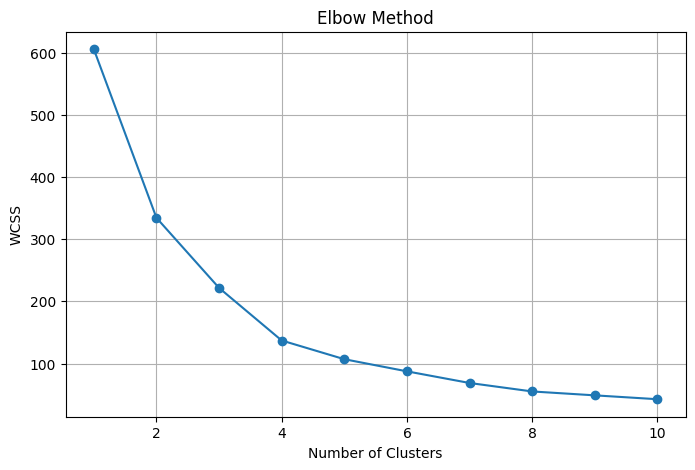


Silhouette Scores
Clusters = 2  Score = 0.422
Clusters = 3  Score = 0.428
Clusters = 4  Score = 0.484
Clusters = 5  Score = 0.487
Clusters = 6  Score = 0.492
Clusters = 7  Score = 0.493
Clusters = 8  Score = 0.484
Clusters = 9  Score = 0.462
Clusters = 10  Score = 0.442

Best Number of Clusters = 7


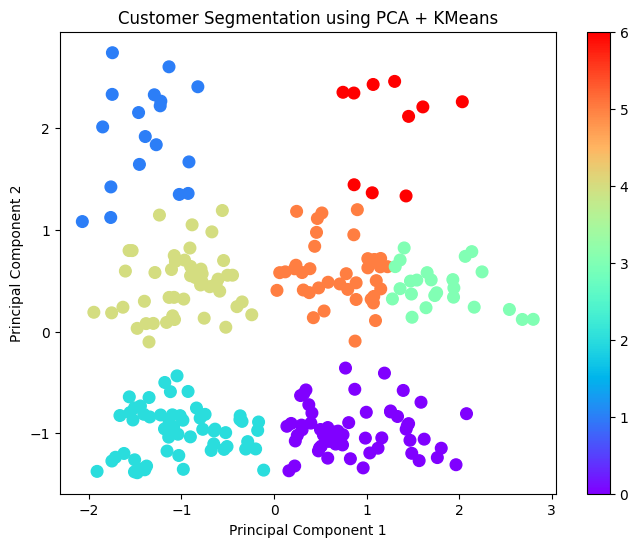

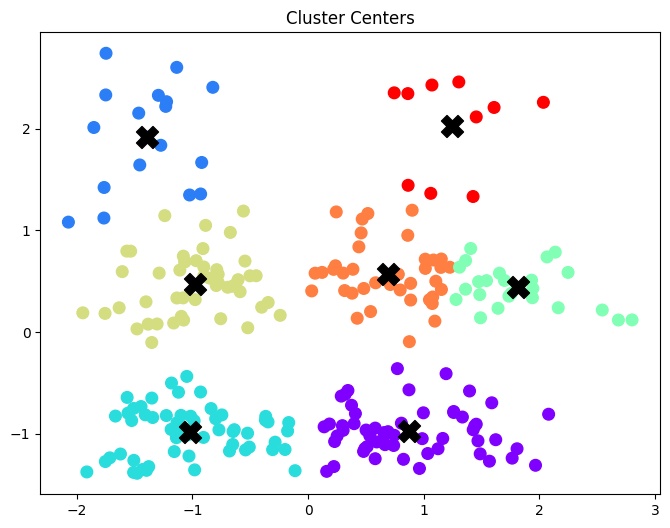


Cluster Summary
           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.000000  48.109091           58.818182               34.781818
1        0.777778  29.555556          256.555556               79.000000
2        0.000000  28.438596           59.666667               67.684211
3        0.916667  59.250000           68.500000               27.916667
4        0.833333  29.041667           88.625000               72.416667
5        0.736842  40.026316          112.605263               27.657895
6        0.900000  48.700000          246.700000               17.100000

Cluster Counts
Cluster
2    57
0    55
4    48
5    38
3    24
1    18
6    10
Name: count, dtype: int64

Project Completed Successfully.
Output file saved as Customer_Segmentation_Output.csv


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv('/content/Mall_Customer.csv')

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# Missing Values
# ==========================================

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================
# Duplicate Values
# ==========================================

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

# ==========================================
# Drop CustomerID
# ==========================================

if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# ==========================================
# Encode Gender
# ==========================================

le = LabelEncoder()

if 'Gender' in df.columns:
    df['Gender'] = le.fit_transform(df['Gender'])

print("\nProcessed Dataset")
print(df.head())

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

# ==========================================
# PCA
# ==========================================

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

print("\nExplained Variance Ratio")
print(pca.explained_variance_ratio_)

# ==========================================
# Elbow Method
# ==========================================

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(pca_data)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# ==========================================
# Silhouette Scores
# ==========================================

print("\nSilhouette Scores")

scores = {}

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(pca_data)

    score = silhouette_score(pca_data, labels)

    scores[k] = score

    print("Clusters =",k," Score =",round(score,3))

best_k = max(scores,key=scores.get)

print("\nBest Number of Clusters =",best_k)

# ==========================================
# Final KMeans Model
# ==========================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(pca_data)

df['Cluster'] = clusters

# ==========================================
# PCA Scatter Plot
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap='rainbow',
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using PCA + KMeans")

plt.colorbar()

plt.show()

# ==========================================
# Cluster Centers
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap='rainbow',
    s=70
)

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='black',
    s=250,
    marker='X'
)

plt.title("Cluster Centers")

plt.show()

# ==========================================
# Cluster Summary
# ==========================================

print("\nCluster Summary")

print(df.groupby('Cluster').mean())

print("\nCluster Counts")

print(df['Cluster'].value_counts())

# ==========================================
# Save Final Dataset
# ==========================================

df.to_csv("Customer_Segmentation_Output.csv",index=False)

print("\nProject Completed Successfully.")
print("Output file saved as Customer_Segmentation_Output.csv")